In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as pyplot 
import seaborn as sns

In [2]:
df = pd.read_csv('weight-height.csv')
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [3]:
df.shape

(10000, 3)

In [4]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

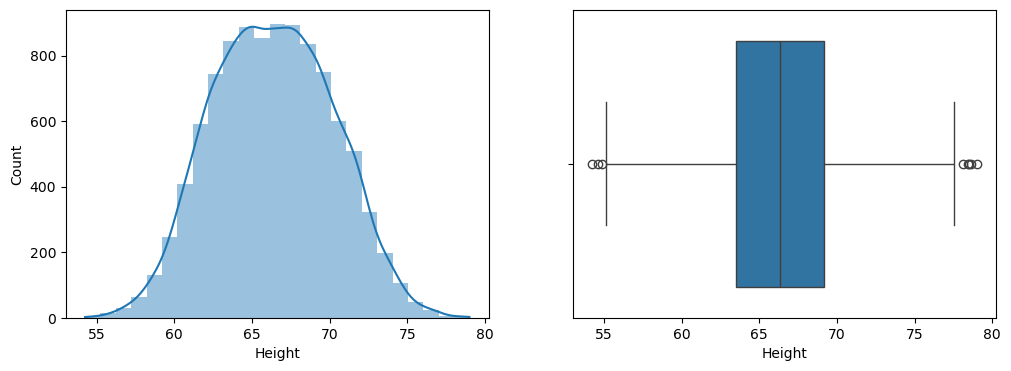

In [12]:
pyplot.figure(figsize=(12,4))
pyplot.subplot(121)
sns.histplot(x=df['Height'], bins=25, kde=True, linewidth=0, alpha=0.45)

pyplot.subplot(122)
sns.boxplot(x=df['Height']) 
pyplot.show()

In [15]:
# we will decide upper_limit and lower_limit to handle outliers 
upper_limit = df['Height'].quantile(0.99)                  # decide yourself    99th percentile
lower_limit = df['Height'].quantile(0.01)            # make sure that both threshold have equal percentile.  (symmetric)

upper_limit, lower_limit

(np.float64(74.7857900583366), np.float64(58.13441158671655))

In [17]:
#  Outliers 
outlier_df = df[(df['Height'] >= upper_limit) | (df['Height'] <= lower_limit)] 

outlier_df.shape

(200, 3)

<h2 style='color:red'>Trimming</h2>

In [18]:
new_df = df[(df['Height'] <= upper_limit) & (df['Height'] >= lower_limit)]

new_df.shape

(9800, 3)

In [22]:
print(df['Height'].describe(), '\n') 
print(new_df['Height'].describe())

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64 

count    9800.000000
mean       66.364366
std         3.645075
min        58.134496
25%        63.577162
50%        66.318070
75%        69.119896
max        74.785714
Name: Height, dtype: float64


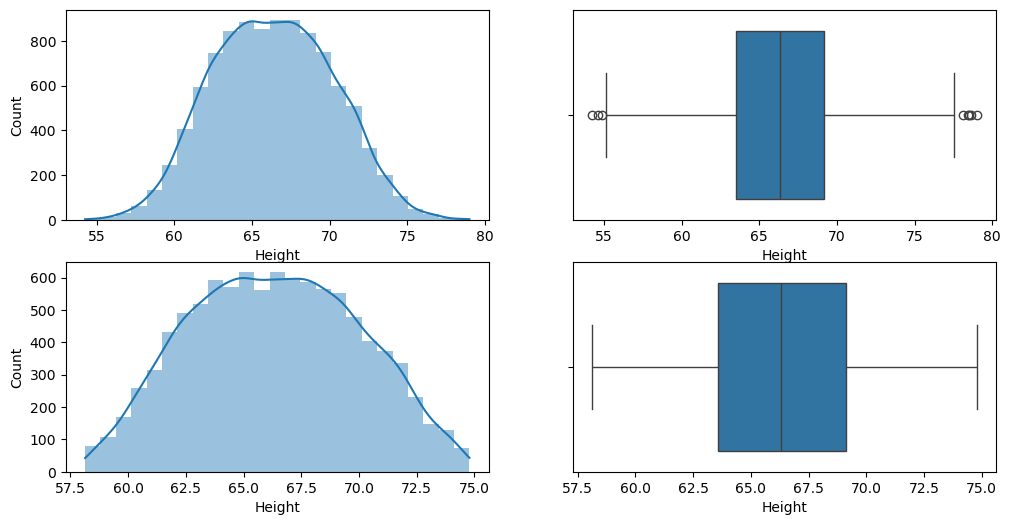

In [23]:
# Comparing before and after removing outliers
pyplot.figure(figsize=(12,6))
pyplot.subplot(221)
sns.histplot(x=df['Height'], bins=25, kde=True, linewidth=0, alpha=0.45)

pyplot.subplot(222)
sns.boxplot(x=df['Height'])

pyplot.subplot(223)
sns.histplot(x=new_df['Height'], bins=25, kde=True, linewidth=0, alpha=0.45)

pyplot.subplot(224)
sns.boxplot(x=new_df['Height'])

pyplot.show()

<h2 style='color:red'>Capping / Winsorization Technique</h2>

In [27]:
# if Capping by Percentile Method   -->  Winsorization Technique
cap_df = df.copy() 

cap_df['Height'] = np.where(
        df['Height'] > upper_limit, 
        upper_limit, 
        np.where(
            df['Height'] < lower_limit, 
            lower_limit,  
            df['Height']
        )
)
cap_df.shape

(10000, 3)

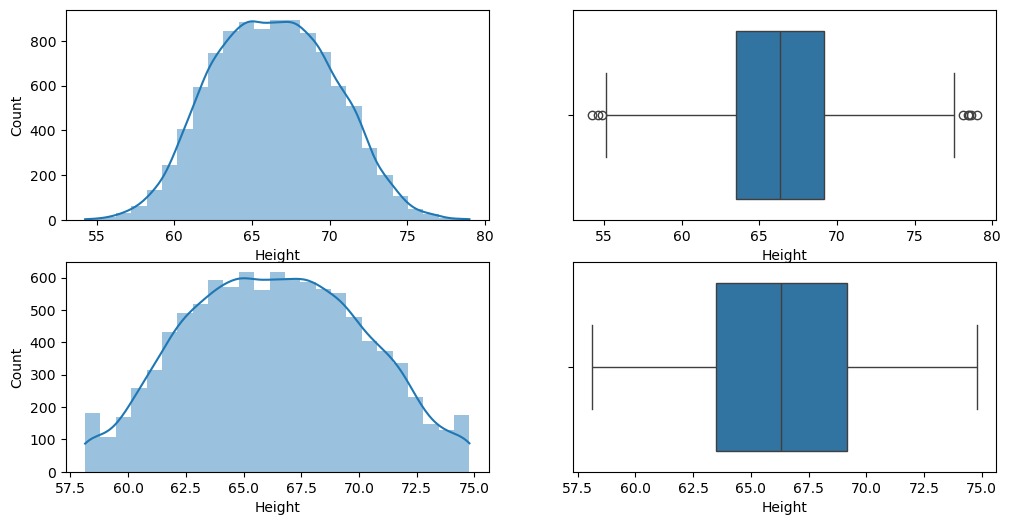

In [29]:
# Comparing before and after removing outliers
pyplot.figure(figsize=(12,6))
pyplot.subplot(221)
sns.histplot(x=df['Height'], bins=25, kde=True, linewidth=0, alpha=0.45)

pyplot.subplot(222)
sns.boxplot(x=df['Height'])

pyplot.subplot(223)
sns.histplot(x=cap_df['Height'], bins=25, kde=True, linewidth=0, alpha=0.45)

pyplot.subplot(224)
sns.boxplot(x=cap_df['Height'])

pyplot.show()